### Modeling the spread of rabies in one dimension

In this notebook, we will move from the 2 connected patches described in [Notebook 8](https://github.com/laser-base/laser-generic/blob/50796ab5a253df168255e8a3ac54b766f6aa55d5/notebooks/08_2patch_SIR_wbirths_correlation.ipynb) to a 1-D grid of connected population patches.  This is the scenario explored to describe the spatial spread of rabies in foxes in the work of [Kallen, Arcuri, and Murray, Journal of Theoretical Biology (1985) 116, 377-393](https://pubmed.ncbi.nlm.nih.gov/4058027/). The relevant model equations (note that these are now PDEs rather than the ODEs of previous notebooks) are:
$$
\frac{\partial S}{\partial t} = -KIS \\

\frac{\partial I}{\partial t} = D \frac{\partial^2 I}{\partial x^2} + KIS - \mu I
$$ 

and come to the conclusion that this system supports traveling waves with velocity bounded below by 

$$
c = 2 \sqrt{D \mu (1/r -1)}
$$

where $r = \frac{\mu}{K S_0}$ and $S_0$ is the initial density of susceptibles.

The analogy to the SIR model equations we have been using is clear, though this model conceptually different in specific ways from that model as we now have spatially dimensional quantities.  For example, I & S are infective/susceptible population densities rather than population counts, which affects translating between the $K$ of this model and the $\beta$ of the SIR; the derived quantity $r$ is clearly analogous to $\frac{1}{R_0}$ of the SIR model, but requires the presence of the initial susceptible density to be properly dimensionless, and rabies being invariably fatal, $\mu$ represents the mortality of rabies rather than the $\gamma$ we would use for recovery.  

With all that said, if we are careful about translation between parameters, and appropriately construct the transmission network to appropriately reflect 1-D diffusion, we ought to be able to reproduce this model in our SIR implementation, and recapitulate the traveling wave behavior of the outbreak.

In [1]:
import numpy as np
import pandas as pd
from laser.core.propertyset import PropertySet
import laser.core.distributions as dists
from laser.core.demographics import AliasedDistribution
from laser.core.demographics import KaplanMeierEstimator
from laser_generic.models import SIR
from laser_generic.models.model import Model
from laser_generic.newutils import ValuesMap
from laser_generic.newutils import grid
import laser.core
import laser_generic
import matplotlib.pyplot as plt
import os
from scipy.optimize import fsolve


print(f"{np.__version__=}")
print(f"{laser.core.__version__=}")
print(f"{laser_generic.__version__=}")


np.__version__='2.3.5'
laser.core.__version__='0.6.0'
laser_generic.__version__='0.0.0'


In [79]:
#Set up the network and initial conditions
npatches = 201
pop = 1000
scenario = grid(M=1, N=npatches, node_size_km=10, population_fn=lambda x,y: pop, origin_x=0, origin_y=0)
initial_infected = 3
scenario["I"] = 0
scenario["R"] = 0
scenario["S"] = scenario.population
scenario.loc[scenario.nodeid==101,"I"] = initial_infected
scenario.loc[scenario.nodeid==101,"S"] = scenario.loc[scenario.nodeid==101,"population"]-initial_infected

# The transmission network
Spatial transmission in this rabies model is contained in the diffusive term $D \frac{\partial^2 I}{\partial x^2}$.  We are operating on a discretized 1-D grid, and will take advantage of the usual way to discretize a second derivative

$$
D \frac{\partial^2 I}{\partial x^2} \rightarrow D \frac {I_{x-h} - 2 I_{x} + I_{x+h}} {h^2}
$$

To translate this into a network structure for the model, we can arbitrarily set the  length scale $h$ to be 1 in units of the grid spacing.  Looking at the above, from the perspective of an arbitrary node $i$, the transmission matrix must "send" $D I_i$ units of infectivity to the adjacent nodes on either side, and remove that infectivity from the local pool.   Looking at the spatial transmission code (line 1006-8 in src/laser_generic/models/components.py), we see that spatial transmission is handled by multiplying the transmission matrix and the vector of infectivities by node, and that it internally handles subtracting the "outbound infectivity" from the local source.  Thus, the above discretization can be accomplished by filling the value $D$ on the first superdiagonal and subdiagonal of the transmission matrix, and 0 everywhere else.

In [89]:
infmean = 6.0
R0 = 10.0
nticks = 10 * 365
D = .01
parameters = PropertySet(
    {
        "seed": np.random.randint(0, 1000000),
        "nticks": nticks,
        "verbose": True,
        "beta": R0 / infmean,
        "inf_mean": infmean,
    }
)

infdurdist = dists.exponential(scale=parameters.inf_mean)
model = Model(scenario, parameters)
model.network = 0*model.network
np.fill_diagonal(model.network[1:], D)
np.fill_diagonal(model.network[:,1:], D)

model.components = [
    SIR.Susceptible(model),
    SIR.Recovered(model),
    SIR.Infectious(model, infdurdist),
    SIR.Transmission(model, infdurdist),
]
model.run()



201000 agents in f201 nodes: 100%|██████████| 3650/3650 [00:01<00:00, 3198.77it/s]


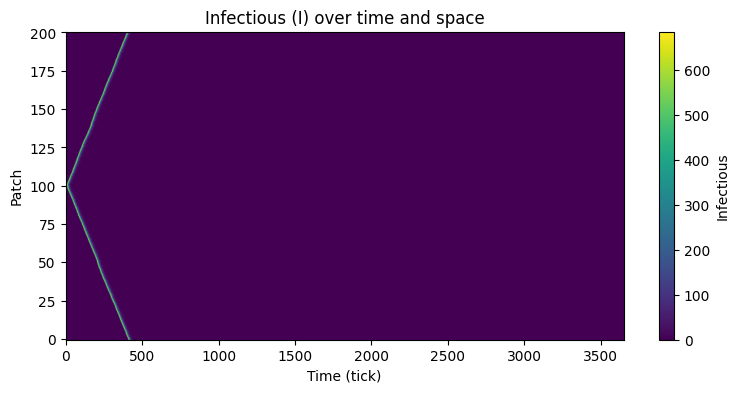

In [90]:
plt.figure(figsize=(9, 4))
plt.imshow(model.nodes.I.T, aspect='auto', origin='lower')
plt.xlabel('Time (tick)')
plt.ylabel('Patch')
plt.title('Infectious (I) over time and space')
plt.colorbar(label='Infectious')
plt.show()


In [91]:
from scipy.stats import linregress

# Find the time (tick) of peak I for each node
peak_times = model.nodes.I.argmax(axis=0)  # shape: (npatches,)

# Get the node indices for right-going (101 to 200) and left-going (100 to 0) waves
right_nodes = np.arange(101, npatches)
left_nodes = np.arange(100, -1, -1)

# Fit a line to peak_times vs node index for each direction to estimate velocity (slope = 1/velocity)

# Right-going wave
right_peak_times = peak_times[right_nodes]
slope_r, intercept_r, r_value_r, p_value_r, std_err_r = linregress(right_nodes[right_peak_times>0], right_peak_times[right_peak_times > 0])
velocity_right = 1 / slope_r if slope_r != 0 else np.nan

# Left-going wave
left_peak_times = peak_times[left_nodes]
slope_l, intercept_l, r_value_l, p_value_l, std_err_l = linregress(left_nodes[left_peak_times>0], left_peak_times[left_peak_times > 0])
velocity_left = -1 / slope_l if slope_l != 0 else np.nan  # negative because left

print(f"Estimated right-going wavespeed: {velocity_right:.3f} patches/tick")
print(f"Estimated left-going wavespeed: {velocity_left:.3f} patches/tick")
print(f"Expected wavespeed: {2*np.sqrt(D/infmean*(R0-1)):.3f} patches/tick")

Estimated right-going wavespeed: 0.253 patches/tick
Estimated left-going wavespeed: 0.249 patches/tick
Expected wavespeed: 0.245 patches/tick


array([ 55, 126, 188, 265, 289, 345, 395, 461, 506, 552, 586, 628, 676,
       706, 730, 720,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0])

In [14]:
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML

# fig, ax = plt.subplots()
# line, = ax.plot([], [], lw=2)
# ax.set_xlim(0, npatches-1)
# ax.set_ylim(0, model.nodes.I.max())
# ax.set_xlabel('Patch x')
# ax.set_ylabel('Infectious (I)')
# ax.set_title('Infectious population over time')

# def init():
#     line.set_data([], [])
#     return line,

# def update(frame):
#     line.set_data(np.arange(npatches), model.nodes.I[frame, :])
#     ax.set_title(f'Infectious population at t={frame}')
#     return line,

# ani = FuncAnimation(fig, update, frames=nticks, init_func=init, blit=True, interval=30)
# HTML(ani.to_jshtml())